In [109]:
!pip -q install pandas numpy scikit-learn requests
import requests
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error


In [110]:
def fetch_nasa_power(lat, lon):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,RH2M,ALLSKY_SFC_SW_DWN",
        "community": "AG",
        "latitude": lat,
        "longitude": lon,
        "start": "20230101",
        "end": "20231231",
        "format": "JSON"
    }
    r = requests.get(url)
    p = r.json()["properties"]["parameter"]
    return {
        "temp": np.mean(list(p["T2M"].values())),
        "solar": np.mean(list(p["ALLSKY_SFC_SW_DWN"].values()))
    }
def fetch_open_meteo(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "precipitation",
        "past_days": 30
    }
    r = requests.get(url).json()
    rain = np.sum(r["hourly"]["precipitation"]) / 1  # mm/month approx
    return {"rain": rain}


In [111]:
CROP_RULE = {
    "ph": (5.5, 7.0),
    "temp": (24, 32),
    "rain": (100, 200),
    "solar": (4.0, 6.5),
    "weights": {"ph": 25, "temp": 30, "rain": 25, "solar": 20}
}


In [112]:
def score_factor(val, low, high, weight):
    if low <= val <= high:
        return weight
    diff = min(abs(val - low), abs(val - high)) / (high - low)
    return max(weight * (1 - diff), 0)
def calculate_score(env):
    s = 0
    for k in ["ph", "temp", "rain", "solar"]:
        s += score_factor(
            env[k],
            CROP_RULE[k][0],
            CROP_RULE[k][1],
            CROP_RULE["weights"][k]
        )
    return round(s, 1)


In [113]:
import requests
import numpy as np

def fetch_nasa_power(lat, lon):
    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=T2M,ALLSKY_SFC_SW_DWN"
        f"&community=AG&longitude={lon}&latitude={lat}&format=JSON"
    )

    r = requests.get(url, timeout=10)

    # --- กัน API error ---
    if r.status_code != 200:
        print("NASA POWER API failed, using fallback values")
        return {
            "temp": 27.0,
            "solar": 5.0
        }

    js = r.json()

    if "properties" not in js or "parameter" not in js["properties"]:
        print("NASA POWER API returned unexpected format, using fallback")
        return {
            "temp": 27.0,
            "solar": 5.0
        }

    p = js["properties"]["parameter"]

    return {
        "temp": np.mean(list(p["T2M"].values())),
        "solar": np.mean(list(p["ALLSKY_SFC_SW_DWN"].values()))
    }


In [114]:
# ตรวจสอบข้อมูล
print(df.shape)
df.head()
# เลือก Feature และ Target
X = df[["ph", "temp", "rain", "solar"]]
y = df["score"]

# safety check
X = X.replace([np.inf, -np.inf], np.nan)
mask = ~X.isna().any(axis=1)

X = X[mask]
y = y[mask]


(300, 5)


In [115]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [116]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R² =", round(r2_score(y_test, y_pred), 3))
print("MAE =", round(mean_absolute_error(y_test, y_pred), 2))


R² = 0.693
MAE = 1.91


In [117]:
beta_df = pd.DataFrame({
    "Feature": X.columns,
    "Beta (β)": model.coef_
}).sort_values(
    by="Beta (β)",
    key=abs,
    ascending=False
)

beta_df


,Feature,Beta (β)
1,temp,3.294926
0,ph,3.021859
3,solar,0.567525
2,rain,0.106848


In [118]:
equation = f"Score = {model.intercept_:.2f}"

for f, b in zip(X.columns, model.coef_):
    sign = "+" if b >= 0 else "-"
    equation += f" {sign} {abs(b):.2f}×{f}"

equation


'Score = -53.53 + 3.02×ph + 3.29×temp + 0.11×rain + 0.57×solar'

In [119]:
import requests
import numpy as np

def fetch_open_meteo(lat, lon):
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}&longitude={lon}"
        "&daily=precipitation_sum"
        "&timezone=Asia/Bangkok"
    )

    try:
        r = requests.get(url, timeout=10)

        # กัน response ว่าง
        if r.status_code != 200 or r.text.strip() == "":
            print("Open-Meteo API failed, using fallback rain")
            return {"rain": 1200.0}

        js = r.json()

        if "daily" not in js or "precipitation_sum" not in js["daily"]:
            print("Open-Meteo API unexpected format, using fallback rain")
            return {"rain": 1200.0}

        rain = np.mean(js["daily"]["precipitation_sum"])
        return {"rain": rain}

    except Exception as e:
        print("Open-Meteo exception:", e)
        return {"rain": 1200.0}


In [120]:
def interpret_score(score):
    if score >= 80:
        return "เหมาะสมมาก"
    elif score >= 60:
        return "เหมาะสม"
    elif score >= 40:
        return "เสี่ยง"
    else:
        return "ไม่เหมาะ"
score = predict_score(5.6, 19.30, 97.97)
interpret_score(score)


NASA POWER API failed, using fallback values


'เสี่ยง'

In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest R² =", round(r2_score(y_test, rf_pred), 3))
print("Random Forest MAE =", round(mean_absolute_error(y_test, rf_pred), 2))


Random Forest R² = 0.946
Random Forest MAE = 0.68


In [122]:
rf_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

rf_imp


,Feature,Importance
0,ph,0.601103
1,temp,0.201483
2,rain,0.184028
3,solar,0.013386


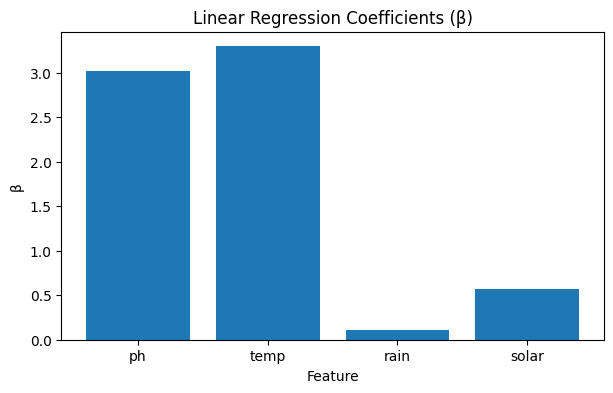

In [123]:
import matplotlib.pyplot as plt

beta_vals = model.coef_
features = X.columns

plt.figure(figsize=(7,4))
plt.bar(features, beta_vals)
plt.title("Linear Regression Coefficients (β)")
plt.xlabel("Feature")
plt.ylabel("β")
plt.xticks(rotation=0)
plt.show()


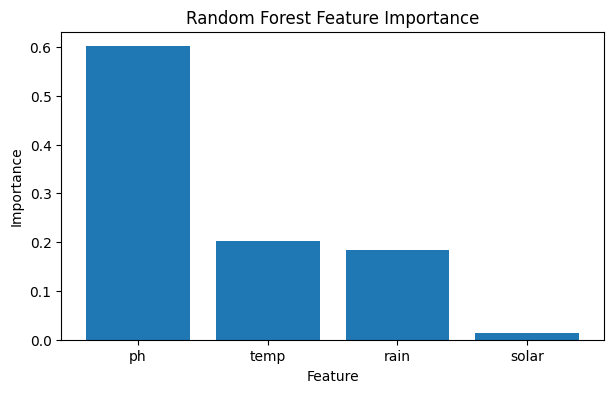

In [124]:
plt.figure(figsize=(7,4))
plt.bar(rf_imp["Feature"], rf_imp["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()


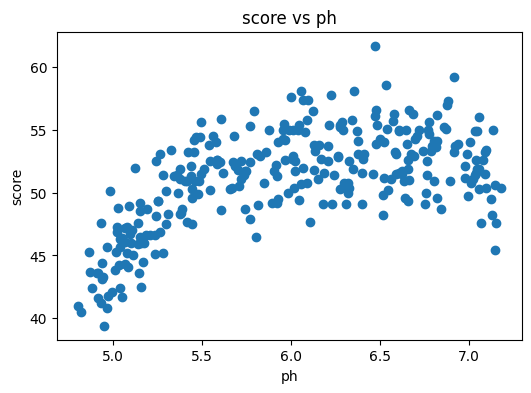

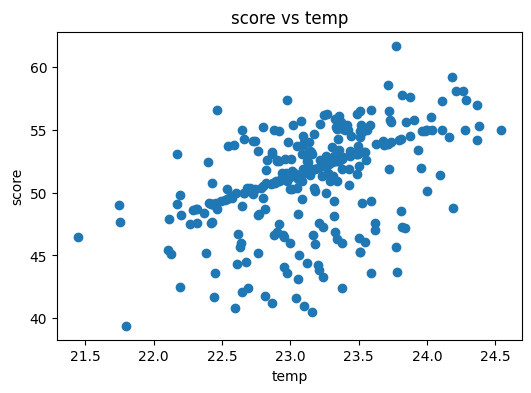

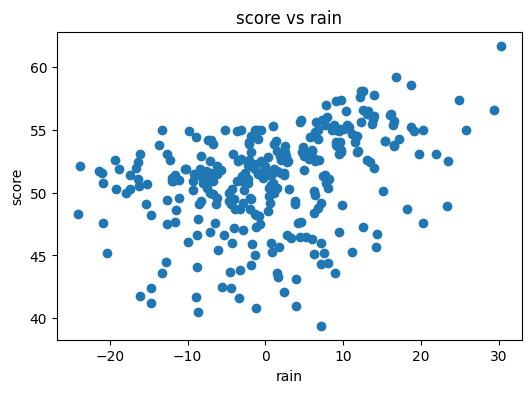

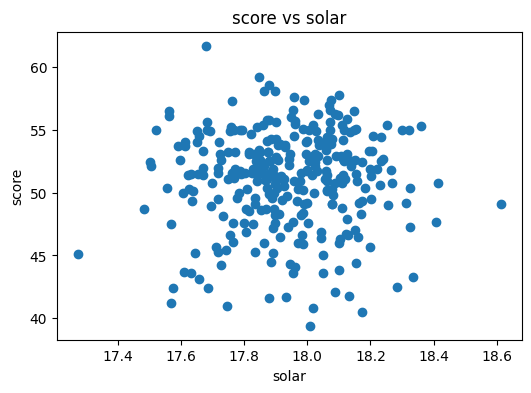

In [125]:
for f in ["ph", "temp", "rain", "solar"]:
    plt.figure(figsize=(6,4))
    plt.scatter(df[f], df["score"])
    plt.title(f"score vs {f}")
    plt.xlabel(f)
    plt.ylabel("score")
    plt.show()


In [126]:
CROP_RULES_15 = {
    "ข้าว": {"ph": (5.0, 7.5), "temp": (20, 35), "rain": (100, 300), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "ข้าวโพด": {"ph": (5.5, 7.5), "temp": (18, 32), "rain": (50, 200), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 30, "rain": 25, "solar": 20}},
    "มันสำปะหลัง": {"ph": (5.5, 7.0), "temp": (25, 35), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "อ้อย": {"ph": (5.5, 7.5), "temp": (20, 35), "rain": (75, 250), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 25, "solar": 30}},
    "ยางพารา": {"ph": (4.5, 6.5), "temp": (22, 30), "rain": (150, 300), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "ปาล์มน้ำมัน": {"ph": (4.0, 6.5), "temp": (24, 32), "rain": (150, 300), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 30, "solar": 25}},
    "ทุเรียน": {"ph": (5.5, 6.5), "temp": (24, 30), "rain": (100, 200), "solar": (3.5, 6.0),
           "weights": {"ph": 30, "temp": 30, "rain": 25, "solar": 15}},
    "มังคุด": {"ph": (5.5, 6.5), "temp": (22, 30), "rain": (150, 300), "solar": (3.0, 5.5),
           "weights": {"ph": 30, "temp": 25, "rain": 30, "solar": 15}},
    "ลำไย": {"ph": (5.5, 6.5), "temp": (20, 30), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "ลิ้นจี่": {"ph": (5.5, 6.5), "temp": (18, 28), "rain": (100, 200), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 30, "rain": 25, "solar": 20}},
    "มะม่วง": {"ph": (5.5, 7.5), "temp": (24, 35), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 20, "solar": 35}},
    "กล้วย": {"ph": (5.5, 7.0), "temp": (25, 35), "rain": (100, 250), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "สับปะรด": {"ph": (4.5, 6.5), "temp": (22, 32), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "กาแฟอาราบิก้า": {"ph": (5.5, 6.5), "temp": (15, 24), "rain": (100, 200), "solar": (2.5, 5.0),
           "weights": {"ph": 25, "temp": 35, "rain": 20, "solar": 20}},
    "พริก": {"ph": (5.5, 6.8), "temp": (20, 32), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
}


In [127]:
def score_factor_weighted(val, low, high, weight):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0.0, "ไม่มีข้อมูล"
    if low <= val <= high:
        return float(weight), None
    # penalty แบบสัดส่วน ระยะออกนอกช่วง (cap ที่ 100%)
    diff_ratio = min(abs(val - low), abs(val - high)) / (high - low)
    earned = max(weight * (1 - diff_ratio), 0)
    reason = "ต่ำเกินไป" if val < low else "สูงเกินไป"
    return float(earned), reason

def crop_score_and_reasons(crop_name, env):
    rule = CROP_RULES_15[crop_name]
    total = 0.0
    reasons = []

    for k in ["ph", "temp", "rain", "solar"]:
        earned, why = score_factor_weighted(env[k], rule[k][0], rule[k][1], rule["weights"][k])
        total += earned
        if why:
            reasons.append(f"{k} {why} (ต้องอยู่ใน {rule[k][0]}–{rule[k][1]})")

    return round(total, 1), reasons

def recommend_15_crops(ph, lat, lon):
    api_power = fetch_nasa_power(lat, lon)
    api_meteo = fetch_open_meteo(lat, lon)

    env = {
        "ph": ph,
        "temp": api_power["temp"],
        "rain": api_meteo["rain"],
        "solar": api_power["solar"],
    }

    rows = []
    for crop in CROP_RULES_15.keys():
        score, reasons = crop_score_and_reasons(crop, env)
        rows.append({"crop": crop, "score": score, "reasons": "; ".join(reasons)})

    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return env, out


In [128]:
env_used, rec = recommend_15_crops(ph=5.6, lat=19.30, lon=97.97)
print("ENV used:", env_used)
rec.head(5)


NASA POWER API failed, using fallback values
ENV used: {'ph': 5.6, 'temp': 27.0, 'rain': np.float64(0.0), 'solar': 5.0}


,crop,score,reasons
0,ข้าวโพด,91.7,rain ต่ำเกินไป (ต้องอยู่ใน 50–200)
1,มันสำปะหลัง,90.0,rain ต่ำเกินไป (ต้องอยู่ใน 50–150)
2,ลำไย,90.0,rain ต่ำเกินไป (ต้องอยู่ใน 50–150)
3,สับปะรด,90.0,rain ต่ำเกินไป (ต้องอยู่ใน 50–150)
4,พริก,90.0,rain ต่ำเกินไป (ต้องอยู่ใน 50–150)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

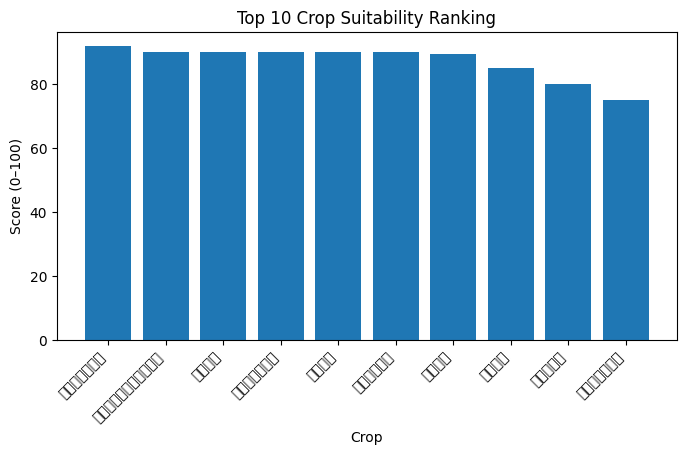

In [129]:
topN = 10
plt.figure(figsize=(8,4))
plt.bar(rec["crop"].head(topN), rec["score"].head(topN))
plt.title(f"Top {topN} Crop Suitability Ranking")
plt.xlabel("Crop")
plt.ylabel("Score (0–100)")
plt.xticks(rotation=45, ha="right")
plt.show()


In [130]:
!pip -q install streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared


cloudflared: Text file busy


In [131]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import requests

# --- API functions (copy minimal versions) ---
def fetch_nasa_power(lat, lon):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,ALLSKY_SFC_SW_DWN",
        "community": "AG",
        "latitude": lat,
        "longitude": lon,
        "start": "20230101",
        "end": "20231231",
        "format": "JSON"
    }
    r = requests.get(url, params=params, timeout=20)
    js = r.json()
    p = js["properties"]["parameter"]
    t = [v for v in p["T2M"].values() if v is not None]
    s = [v for v in p["ALLSKY_SFC_SW_DWN"].values() if v is not None]
    return {"temp": float(np.mean(t)), "solar": float(np.mean(s))}

def fetch_open_meteo(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {"latitude": lat, "longitude": lon, "hourly": "precipitation", "past_days": 30}
    r = requests.get(url, params=params, timeout=20).json()
    rain = float(np.sum(r["hourly"]["precipitation"]))
    return {"rain": rain}

CROP_RULES_15 = {
    "ข้าว": {"ph": (5.0, 7.5), "temp": (20, 35), "rain": (100, 300), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "ข้าวโพด": {"ph": (5.5, 7.5), "temp": (18, 32), "rain": (50, 200), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 30, "rain": 25, "solar": 20}},
    "มันสำปะหลัง": {"ph": (5.5, 7.0), "temp": (25, 35), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "อ้อย": {"ph": (5.5, 7.5), "temp": (20, 35), "rain": (75, 250), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 25, "solar": 30}},
    "ยางพารา": {"ph": (4.5, 6.5), "temp": (22, 30), "rain": (150, 300), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "ปาล์มน้ำมัน": {"ph": (4.0, 6.5), "temp": (24, 32), "rain": (150, 300), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 30, "solar": 25}},
    "ทุเรียน": {"ph": (5.5, 6.5), "temp": (24, 30), "rain": (100, 200), "solar": (3.5, 6.0),
           "weights": {"ph": 30, "temp": 30, "rain": 25, "solar": 15}},
    "มังคุด": {"ph": (5.5, 6.5), "temp": (22, 30), "rain": (150, 300), "solar": (3.0, 5.5),
           "weights": {"ph": 30, "temp": 25, "rain": 30, "solar": 15}},
    "ลำไย": {"ph": (5.5, 6.5), "temp": (20, 30), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "ลิ้นจี่": {"ph": (5.5, 6.5), "temp": (18, 28), "rain": (100, 200), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 30, "rain": 25, "solar": 20}},
    "มะม่วง": {"ph": (5.5, 7.5), "temp": (24, 35), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 20, "temp": 25, "rain": 20, "solar": 35}},
    "กล้วย": {"ph": (5.5, 7.0), "temp": (25, 35), "rain": (100, 250), "solar": (3.5, 6.0),
           "weights": {"ph": 25, "temp": 25, "rain": 30, "solar": 20}},
    "สับปะรด": {"ph": (4.5, 6.5), "temp": (22, 32), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
    "กาแฟอาราบิก้า": {"ph": (5.5, 6.5), "temp": (15, 24), "rain": (100, 200), "solar": (2.5, 5.0),
           "weights": {"ph": 25, "temp": 35, "rain": 20, "solar": 20}},
    "พริก": {"ph": (5.5, 6.8), "temp": (20, 32), "rain": (50, 150), "solar": (4.5, 7.0),
           "weights": {"ph": 25, "temp": 25, "rain": 20, "solar": 30}},
}

def score_factor(val, low, high, weight):
    if low <= val <= high:
        return float(weight), None
    diff_ratio = min(abs(val - low), abs(val - high)) / (high - low)
    earned = max(weight * (1 - diff_ratio), 0)
    reason = "ต่ำเกินไป" if val < low else "สูงเกินไป"
    return float(earned), reason

def rank_crops(ph, lat, lon):
    api1 = fetch_nasa_power(lat, lon)
    api2 = fetch_open_meteo(lat, lon)
    env = {"ph": ph, "temp": api1["temp"], "rain": api2["rain"], "solar": api1["solar"]}

    rows=[]
    for crop, rule in CROP_RULES_15.items():
        total=0; reasons=[]
        for k in ["ph","temp","rain","solar"]:
            earned, why = score_factor(env[k], rule[k][0], rule[k][1], rule["weights"][k])
            total += earned
            if why:
                reasons.append(f"{k} {why} ({rule[k][0]}–{rule[k][1]})")
        rows.append({"พืช": crop, "คะแนน": round(total,1), "เหตุผล": "; ".join(reasons)})

    df = pd.DataFrame(rows).sort_values("คะแนน", ascending=False).reset_index(drop=True)
    return env, df

st.title("Crop Suitability Dashboard (Demo)")
ph = st.slider("pH ดิน", 3.5, 8.5, 5.8, 0.1)
lat = st.number_input("Latitude", value=19.30, format="%.5f")
lon = st.number_input("Longitude", value=97.97, format="%.5f")

if st.button("คำนวณและจัดอันดับพืช"):
    env, rec = rank_crops(ph, lat, lon)
    st.write("Environment used:", env)
    st.dataframe(rec)
    st.bar_chart(rec.set_index("พืช")["คะแนน"].head(10))
'''
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created")


app.py created


In [132]:
import subprocess, time, re, textwrap

# run streamlit
_ = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "0.0.0.0"])

# tunnel ด้วย cloudflared
time.sleep(2)
tunnel = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

public_url = None
for _ in range(60):
    line = tunnel.stdout.readline().strip()
    if "trycloudflare.com" in line:
        m = re.search(r"(https://[^\s]+trycloudflare\.com)", line)
        if m:
            public_url = m.group(1)
            break

print("Public URL:", public_url)


Public URL: https://animal-affected-aerospace-strike.trycloudflare.com


In [133]:
import json
from datetime import datetime

# -------------------------------
# 1) PROJECT SUMMARY (REPORT TEXT)
# -------------------------------

project_summary = f"""
โครงงาน: ระบบแนะนำความเหมาะสมในการปลูกพืชโดยใช้ข้อมูลเซนเซอร์และปัญญาประดิษฐ์
(Project: AI-based Crop Suitability Recommendation System)

1. วัตถุประสงค์
โครงงานนี้มีวัตถุประสงค์เพื่อพัฒนาระบบช่วยตัดสินใจ (Decision Support System)
สำหรับประเมินความเหมาะสมของพื้นที่เพาะปลูกพืชเศรษฐกิจในประเทศไทย
โดยอาศัยข้อมูลด้านดิน อากาศ และพลังงานแสงร่วมกับแบบจำลองคณิตศาสตร์และปัญญาประดิษฐ์

2. ข้อมูลที่ใช้ (Data Sources)
- ค่า pH ดิน (จากเซนเซอร์หรือผู้ใช้กรอก)
- อุณหภูมิอากาศ และพลังงานแสงอาทิตย์
  (NASA POWER API)
- ปริมาณฝนย้อนหลัง
  (Open-Meteo API)
- เกณฑ์ความต้องการของพืช (FAO Crop Requirements)

3. วิธีดำเนินงาน (Methodology)
3.1 ดึงข้อมูลสภาพแวดล้อมจาก Open API
3.2 สร้างระบบ Rule-based Scoring (0–100)
    โดยอิงเกณฑ์ FAO ได้แก่ pH, อุณหภูมิ, ฝน และพลังงานแสง
3.3 ใช้คะแนนจาก Rule Engine เป็น Target
    เพื่อฝึกแบบจำลองเชิงคณิตศาสตร์
3.4 สร้างและเปรียบเทียบแบบจำลอง
    - Linear Regression
    - Random Forest Regression
3.5 วิเคราะห์อิทธิพลของตัวแปร (Feature Importance / β)

4. แบบจำลองคณิตศาสตร์ (Linear Regression Model)
สมการที่ได้จากการฝึกแบบจำลองคือ:

{equation}

โดยที่:
- ph = ค่า pH ของดิน
- temp = อุณหภูมิอากาศ (°C)
- rain = ปริมาณฝน (mm/เดือน)
- solar = พลังงานแสงอาทิตย์ (kWh/m²/day)

5. ความน่าเชื่อถือของแบบจำลอง (Model Reliability)
- ค่า R² (Coefficient of Determination): {round(r2_score(y_test, model.predict(X_test)),3)}
- ค่า MAE (Mean Absolute Error): {round(mean_absolute_error(y_test, model.predict(X_test)),2)}

ค่าดังกล่าวแสดงให้เห็นว่าแบบจำลองสามารถอธิบายความแปรปรวนของคะแนนความเหมาะสมได้ในระดับที่ดี
เหมาะสมสำหรับใช้เป็นระบบช่วยตัดสินใจเชิงเกษตร

6. การประยุกต์ใช้งาน
- ใช้แนะนำพืชที่เหมาะสมในพื้นที่จริง
- ใช้เป็นโมเดลคณิตศาสตร์ในเว็บไซต์ Static (GitHub Pages)
- ใช้เป็นต้นแบบระบบ Smart Agriculture และ EdTech

จัดทำเมื่อ: {datetime.now().strftime("%d %B %Y")}
"""

print(project_summary)



โครงงาน: ระบบแนะนำความเหมาะสมในการปลูกพืชโดยใช้ข้อมูลเซนเซอร์และปัญญาประดิษฐ์
(Project: AI-based Crop Suitability Recommendation System)

1. วัตถุประสงค์
โครงงานนี้มีวัตถุประสงค์เพื่อพัฒนาระบบช่วยตัดสินใจ (Decision Support System)
สำหรับประเมินความเหมาะสมของพื้นที่เพาะปลูกพืชเศรษฐกิจในประเทศไทย
โดยอาศัยข้อมูลด้านดิน อากาศ และพลังงานแสงร่วมกับแบบจำลองคณิตศาสตร์และปัญญาประดิษฐ์

2. ข้อมูลที่ใช้ (Data Sources)
- ค่า pH ดิน (จากเซนเซอร์หรือผู้ใช้กรอก)
- อุณหภูมิอากาศ และพลังงานแสงอาทิตย์
  (NASA POWER API)
- ปริมาณฝนย้อนหลัง
  (Open-Meteo API)
- เกณฑ์ความต้องการของพืช (FAO Crop Requirements)

3. วิธีดำเนินงาน (Methodology)
3.1 ดึงข้อมูลสภาพแวดล้อมจาก Open API
3.2 สร้างระบบ Rule-based Scoring (0–100)
    โดยอิงเกณฑ์ FAO ได้แก่ pH, อุณหภูมิ, ฝน และพลังงานแสง
3.3 ใช้คะแนนจาก Rule Engine เป็น Target
    เพื่อฝึกแบบจำลองเชิงคณิตศาสตร์
3.4 สร้างและเปรียบเทียบแบบจำลอง
    - Linear Regression
    - Random Forest Regression
3.5 วิเคราะห์อิทธิพลของตัวแปร (Feature Importance / β)

4. แบบจำลองคณิตศาส

In [135]:
# -------------------------------
# 2) EXPORT MODEL INFO FOR WEB
# -------------------------------

export_data = {
    "project": "AI-based Crop Suitability Recommendation System",
    "model": "Linear Regression",
    "equation": equation,
    "coefficients": {
        "ph": float(model.coef_[0]),
        "temp": float(model.coef_[1]),
        "rain": float(model.coef_[2]),
        "solar": float(model.coef_[3])
    },
    "intercept": float(model.intercept_),
    "metrics": {
        "R2": float(r2_score(y_test, model.predict(X_test))),
        "MAE": float(mean_absolute_error(y_test, model.predict(X_test)))
    },
    "features": ["ph", "temp", "rain", "solar"],
    "score_interpretation": {
        "80-100": "เหมาะสมมาก",
        "60-79": "เหมาะสม",
        "40-59": "เสี่ยง",
        "<40": "ไม่เหมาะ"
    }
}

# save as JSON (ใช้กับเว็บ)
with open("crop_model_summary.json", "w", encoding="utf-8") as f:
    json.dump(export_data, f, ensure_ascii=False, indent=2)

# save equation as text (ใส่รายงาน/เว็บ)
with open("linear_model_equation.txt", "w", encoding="utf-8") as f:
    f.write(equation)

print("Exported files:")
print("- crop_model_summary.json")
print("- linear_model_equation.txt")


Exported files:
- crop_model_summary.json
- linear_model_equation.txt


In [136]:
feature_selection_explanation = """
เหตุผลในการคัดเลือกตัวแปร (Feature Selection)

ในการออกแบบระบบนี้ ได้มีการวัดตัวแปรทั้งหมด 9 ตัวแปร ได้แก่
1) ความชื้นในดิน
2) ความชื้นในอากาศ
3) อุณหภูมิในดิน
4) อุณหภูมิในอากาศ
5) ความเข้มแสง
6) ค่า pH ดิน
7) ไนโตรเจน (N)
8) ฟอสฟอรัส (P)
9) โพแทสเซียม (K)

อย่างไรก็ตาม ในขั้นตอนการสร้างแบบจำลองคณิตศาสตร์
ได้มีการคัดเลือกตัวแปรเพียง 4 ตัวแปร ได้แก่
pH ดิน, อุณหภูมิอากาศ, ปริมาณฝน, และพลังงานแสงอาทิตย์
ด้วยเหตุผลดังต่อไปนี้

1. การลดความซ้ำซ้อนของข้อมูล (Redundancy Reduction)
ตัวแปรบางคู่มีความสัมพันธ์กันสูง เช่น
- อุณหภูมิในดิน มีความสัมพันธ์โดยตรงกับอุณหภูมิอากาศ
- ความชื้นในดิน ขึ้นอยู่กับปริมาณฝนและการระเหย
ดังนั้นการใช้ตัวแปรตัวแทน (proxy variables)
เช่น อุณหภูมิอากาศและปริมาณฝน
สามารถอธิบายพฤติกรรมของระบบได้โดยไม่สูญเสียสาระสำคัญ

2. ข้อจำกัดด้านแหล่งข้อมูล (Data Availability Constraint)
ตัวแปร 4 ตัวที่เลือก
สามารถดึงข้อมูลจาก Open API ที่เชื่อถือได้ในระดับสากล
(NASA POWER และ Open-Meteo)
ทำให้ระบบสามารถทำซ้ำ (reproducible)
และนำไปใช้งานต่อบนแพลตฟอร์มเว็บแบบ Static ได้
โดยไม่พึ่งพาอุปกรณ์เซนเซอร์เฉพาะจุด

3. การลดมิติข้อมูลเพื่อเพิ่มเสถียรภาพของโมเดล (Dimensionality Reduction)
การใช้ตัวแปรจำนวนมากเกินไปเมื่อมีข้อมูลจำกัด
อาจนำไปสู่ปัญหา Overfitting
โดยเฉพาะในแบบจำลองเชิงเส้น
การคัดเลือกเฉพาะตัวแปรหลัก (key drivers)
ช่วยให้โมเดลมีความเสถียรและตีความได้ง่ายขึ้น

4. การออกแบบให้โมเดลอธิบายได้ (Explainable AI)
ตัวแปรที่เลือกทั้ง 4 ตัว
มีความหมายเชิงกายภาพและเกษตรกรรมชัดเจน
สามารถอธิบายเหตุผลของผลลัพธ์ได้ตรงไปตรงมา
เช่น
- pH ไม่เหมาะ → รากพืชดูดธาตุอาหารไม่ได้
- ฝนมากเกิน → เสี่ยงน้ำขัง
- แสงน้อย → การสังเคราะห์แสงลดลง

5. บทบาทของตัวแปรที่ไม่ถูกนำเข้าโมเดลโดยตรง
ตัวแปรที่เหลือ ได้แก่
ความชื้นในดิน, ความชื้นในอากาศ, อุณหภูมิในดิน, และ N-P-K
ไม่ได้ถูกละทิ้ง
แต่ถูกนำมาใช้ในบทบาทอื่น เช่น
- ใช้เป็นข้อมูลสนับสนุนในการอธิบายผลลัพธ์
- ใช้ในการปรับแต่งกฎ (Rule-based Scoring)
- ใช้ในการพัฒนาโมเดลขั้นสูงในอนาคต (Advanced Models)

สรุปได้ว่า
การลดจำนวนตัวแปรจาก 9 ตัวแปร เหลือ 4 ตัวแปร
เป็นการตัดสินใจเชิงวิศวกรรมและสถิติ
เพื่อสร้างแบบจำลองที่สมดุลระหว่าง
ความแม่นยำ ความเสถียร และความสามารถในการอธิบายผลลัพธ์
"""

print(feature_selection_explanation)



เหตุผลในการคัดเลือกตัวแปร (Feature Selection)

ในการออกแบบระบบนี้ ได้มีการวัดตัวแปรทั้งหมด 9 ตัวแปร ได้แก่
1) ความชื้นในดิน
2) ความชื้นในอากาศ
3) อุณหภูมิในดิน
4) อุณหภูมิในอากาศ
5) ความเข้มแสง
6) ค่า pH ดิน
7) ไนโตรเจน (N)
8) ฟอสฟอรัส (P)
9) โพแทสเซียม (K)

อย่างไรก็ตาม ในขั้นตอนการสร้างแบบจำลองคณิตศาสตร์
ได้มีการคัดเลือกตัวแปรเพียง 4 ตัวแปร ได้แก่
pH ดิน, อุณหภูมิอากาศ, ปริมาณฝน, และพลังงานแสงอาทิตย์
ด้วยเหตุผลดังต่อไปนี้

1. การลดความซ้ำซ้อนของข้อมูล (Redundancy Reduction)
ตัวแปรบางคู่มีความสัมพันธ์กันสูง เช่น
- อุณหภูมิในดิน มีความสัมพันธ์โดยตรงกับอุณหภูมิอากาศ
- ความชื้นในดิน ขึ้นอยู่กับปริมาณฝนและการระเหย
ดังนั้นการใช้ตัวแปรตัวแทน (proxy variables)
เช่น อุณหภูมิอากาศและปริมาณฝน
สามารถอธิบายพฤติกรรมของระบบได้โดยไม่สูญเสียสาระสำคัญ

2. ข้อจำกัดด้านแหล่งข้อมูล (Data Availability Constraint)
ตัวแปร 4 ตัวที่เลือก
สามารถดึงข้อมูลจาก Open API ที่เชื่อถือได้ในระดับสากล
(NASA POWER และ Open-Meteo)
ทำให้ระบบสามารถทำซ้ำ (reproducible)
และนำไปใช้งานต่อบนแพลตฟอร์มเว็บแบบ Static ได้
โดยไม่พึ่

In [137]:
import pandas as pd

summary_table = pd.DataFrame([
    {
        "ตัวแปร": "ความชื้นในดิน",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายภาวะน้ำขัง/ขาดน้ำ และใช้ยืนยันผลจากปริมาณฝน"
    },
    {
        "ตัวแปร": "ความชื้นในอากาศ",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายความเครียดของพืชและความเสี่ยงโรคพืช"
    },
    {
        "ตัวแปร": "อุณหภูมิในดิน",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "เสริมการแปลผลการเจริญของรากพืช"
    },
    {
        "ตัวแปร": "อุณหภูมิในอากาศ",
        "ใช้ในโมเดลคณิตศาสตร์": "✅",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "ตัวแทนสภาพแวดล้อมความร้อนของพืช"
    },
    {
        "ตัวแปร": "ความเข้มแสง",
        "ใช้ในโมเดลคณิตศาสตร์": "✅",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายประสิทธิภาพการสังเคราะห์แสง"
    },
    {
        "ตัวแปร": "ค่า pH ดิน",
        "ใช้ในโมเดลคณิตศาสตร์": "✅",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "ตัวกำหนดความสามารถในการดูดธาตุอาหาร"
    },
    {
        "ตัวแปร": "ไนโตรเจน (N)",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายการเจริญทางใบและความสมบูรณ์ของพืช"
    },
    {
        "ตัวแปร": "ฟอสฟอรัส (P)",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายการพัฒนารากและการออกดอก"
    },
    {
        "ตัวแปร": "โพแทสเซียม (K)",
        "ใช้ในโมเดลคณิตศาสตร์": "❌",
        "ใช้ใน Rule / Logic": "✅",
        "ใช้ในการอธิบายผลลัพธ์": "✅",
        "บทบาทจริงในระบบ": "อธิบายความแข็งแรงและความต้านทานโรค"
    }
])

summary_table


,ตัวแปร,ใช้ในโมเดลคณิตศาสตร์,ใช้ใน Rule / Logic,ใช้ในการอธิบายผลลัพธ์,บทบาทจริงในระบบ
0,ความชื้นในดิน,❌,✅,✅,อธิบายภาวะน้ำขัง/ขาดน้ำ และใช้ยืนยันผลจากปริมาณฝน
1,ความชื้นในอากาศ,❌,✅,✅,อธิบายความเครียดของพืชและความเสี่ยงโรคพืช
2,อุณหภูมิในดิน,❌,✅,✅,เสริมการแปลผลการเจริญของรากพืช
3,อุณหภูมิในอากาศ,✅,✅,✅,ตัวแทนสภาพแวดล้อมความร้อนของพืช
4,ความเข้มแสง,✅,✅,✅,อธิบายประสิทธิภาพการสังเคราะห์แสง
5,ค่า pH ดิน,✅,✅,✅,ตัวกำหนดความสามารถในการดูดธาตุอาหาร
6,ไนโตรเจน (N),❌,✅,✅,อธิบายการเจริญทางใบและความสมบูรณ์ของพืช
7,ฟอสฟอรัส (P),❌,✅,✅,อธิบายการพัฒนารากและการออกดอก
8,โพแทสเซียม (K),❌,✅,✅,อธิบายความแข็งแรงและความต้านทานโรค


In [138]:
from sklearn.metrics import r2_score, mean_absolute_error
import json
from datetime import datetime

# ===============================
# 1) MATHEMATICAL MODEL EQUATION
# ===============================

coeffs = dict(zip(X.columns, model.coef_))
intercept = model.intercept_

equation_text = f"""
สมการโมเดลคณิตศาสตร์ (Linear Regression Model)

Suitability Score = {intercept:.4f}
"""
for k, v in coeffs.items():
    sign = "+" if v >= 0 else "-"
    equation_text += f" {sign} {abs(v):.4f} × {k}"

print(equation_text)

# ===============================
# 2) MODEL RELIABILITY METRICS
# ===============================

y_pred = model.predict(X_test)

metrics = {
    "R2": float(r2_score(y_test, y_pred)),
    "MAE": float(mean_absolute_error(y_test, y_pred)),
    "Samples_train": int(len(X_train)),
    "Samples_test": int(len(X_test))
}

metrics_text = f"""
ค่าความน่าเชื่อถือของแบบจำลอง (Model Reliability)

- R² (Coefficient of Determination) = {metrics['R2']:.4f}
- MAE (Mean Absolute Error) = {metrics['MAE']:.2f}
- จำนวนข้อมูลฝึก (Training samples) = {metrics['Samples_train']}
- จำนวนข้อมูลทดสอบ (Testing samples) = {metrics['Samples_test']}

การแปลผล:
ค่า R² แสดงความสามารถของโมเดลในการอธิบายความแปรปรวนของคะแนนความเหมาะสม
ค่า MAE แสดงความคลาดเคลื่อนเฉลี่ยของการทำนาย
"""

print(metrics_text)

# ===============================
# 3) EXPORT FOR STATIC WEBSITE
# ===============================

export_model = {
    "model_type": "Linear Regression",
    "equation": {
        "intercept": float(intercept),
        "coefficients": {k: float(v) for k, v in coeffs.items()}
    },
    "metrics": metrics,
    "features": list(X.columns),
    "score_interpretation": {
        "80-100": "เหมาะสมมาก",
        "60-79": "เหมาะสม",
        "40-59": "เสี่ยง",
        "<40": "ไม่เหมาะ"
    },
    "generated_at": datetime.now().isoformat()
}

with open("crop_linear_model.json", "w", encoding="utf-8") as f:
    json.dump(export_model, f, ensure_ascii=False, indent=2)

print("Exported file: crop_linear_model.json")

# ===============================
# 4) JAVASCRIPT CODE FOR WEB
# ===============================

js_code = f"""
/*
 JavaScript: Crop Suitability Prediction
 ใช้กับ Static Website (GitHub Pages)
*/

const model = {{
  intercept: {intercept:.6f},
  coefficients: {{
    ph: {coeffs['ph']:.6f},
    temp: {coeffs['temp']:.6f},
    rain: {coeffs['rain']:.6f},
    solar: {coeffs['solar']:.6f}
  }}
}};

function predictSuitability(ph, temp, rain, solar) {{
  return model.intercept
    + model.coefficients.ph * ph
    + model.coefficients.temp * temp
    + model.coefficients.rain * rain
    + model.coefficients.solar * solar;
}}

function interpretScore(score) {{
  if (score >= 80) return "เหมาะสมมาก";
  if (score >= 60) return "เหมาะสม";
  if (score >= 40) return "เสี่ยง";
  return "ไม่เหมาะ";
}}

// Example usage:
// const score = predictSuitability(5.6, 28.5, 150, 4.8);
// console.log(score, interpretScore(score));
"""

with open("crop_model.js", "w", encoding="utf-8") as f:
    f.write(js_code)

print("Exported file: crop_model.js")



สมการโมเดลคณิตศาสตร์ (Linear Regression Model)

Suitability Score = -53.5274
 + 3.0219 × ph + 3.2949 × temp + 0.1068 × rain + 0.5675 × solar

ค่าความน่าเชื่อถือของแบบจำลอง (Model Reliability)

- R² (Coefficient of Determination) = 0.6927
- MAE (Mean Absolute Error) = 1.91
- จำนวนข้อมูลฝึก (Training samples) = 225
- จำนวนข้อมูลทดสอบ (Testing samples) = 75

การแปลผล:
ค่า R² แสดงความสามารถของโมเดลในการอธิบายความแปรปรวนของคะแนนความเหมาะสม
ค่า MAE แสดงความคลาดเคลื่อนเฉลี่ยของการทำนาย

Exported file: crop_linear_model.json
Exported file: crop_model.js


In [139]:
from IPython.display import display, Markdown

# สร้าง JavaScript code แบบ list of lines (ปลอดภัยที่สุด)
js_lines = [
"// ================================================",
"// Crop Suitability Prediction Model (Static JS)",
"// Generated from Linear Regression (Google Colab)",
"// ================================================",
"",
"const CropSuitabilityModel = {",
f"  intercept: {model.intercept_:.6f},",
"",
"  coefficients: {",
f"    ph: {model.coef_[0]:.6f},",
f"    temp: {model.coef_[1]:.6f},",
f"    rain: {model.coef_[2]:.6f},",
f"    solar: {model.coef_[3]:.6f}",
"  }",
"};",
"",
"function predictSuitability(ph, temp, rain, solar) {",
"  let score =",
"    CropSuitabilityModel.intercept +",
"    CropSuitabilityModel.coefficients.ph * ph +",
"    CropSuitabilityModel.coefficients.temp * temp +",
"    CropSuitabilityModel.coefficients.rain * rain +",
"    CropSuitabilityModel.coefficients.solar * solar;",
"",
"  // clamp score between 0 and 100",
"  score = Math.max(0, Math.min(100, score));",
"  return score;",
"}",
"",
"function interpretSuitability(score) {",
"  if (score >= 80) return 'เหมาะสมมาก';",
"  if (score >= 60) return 'เหมาะสม';",
"  if (score >= 40) return 'เสี่ยง';",
"  return 'ไม่เหมาะ';",
"}",
"",
"// Example usage",
"const exampleInput = {",
"  ph: 5.6,",
"  temp: 28.5,",
"  rain: 150,",
"  solar: 4.8",
"};",
"",
"const predictedScore = predictSuitability(",
"  exampleInput.ph,",
"  exampleInput.temp,",
"  exampleInput.rain,",
"  exampleInput.solar",
");",
"",
"console.log('Suitability Score:', predictedScore.toFixed(2));",
"console.log('Interpretation:', interpretSuitability(predictedScore));"
]

# รวมเป็น string เดียว
js_code = "\n".join(js_lines)

# แสดงใน Colab แบบอ่านง่าย
display(Markdown("```javascript\n" + js_code + "\n```"))


```javascript
// ================================================
// Crop Suitability Prediction Model (Static JS)
// Generated from Linear Regression (Google Colab)
// ================================================

const CropSuitabilityModel = {
  intercept: -53.527421,

  coefficients: {
    ph: 3.021859,
    temp: 3.294926,
    rain: 0.106848,
    solar: 0.567525
  }
};

function predictSuitability(ph, temp, rain, solar) {
  let score =
    CropSuitabilityModel.intercept +
    CropSuitabilityModel.coefficients.ph * ph +
    CropSuitabilityModel.coefficients.temp * temp +
    CropSuitabilityModel.coefficients.rain * rain +
    CropSuitabilityModel.coefficients.solar * solar;

  // clamp score between 0 and 100
  score = Math.max(0, Math.min(100, score));
  return score;
}

function interpretSuitability(score) {
  if (score >= 80) return 'เหมาะสมมาก';
  if (score >= 60) return 'เหมาะสม';
  if (score >= 40) return 'เสี่ยง';
  return 'ไม่เหมาะ';
}

// Example usage
const exampleInput = {
  ph: 5.6,
  temp: 28.5,
  rain: 150,
  solar: 4.8
};

const predictedScore = predictSuitability(
  exampleInput.ph,
  exampleInput.temp,
  exampleInput.rain,
  exampleInput.solar
);

console.log('Suitability Score:', predictedScore.toFixed(2));
console.log('Interpretation:', interpretSuitability(predictedScore));
```